Found 4541 images.


Extracting ORB features:   0%|          | 0/4541 [00:00<?, ?it/s]

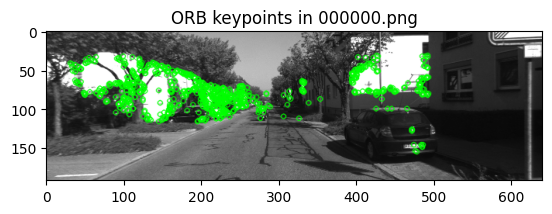

Extracting ORB features:   0%|          | 1/4541 [00:00<18:20,  4.13it/s]

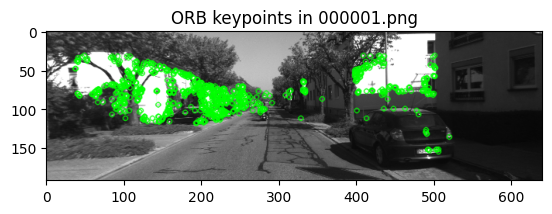

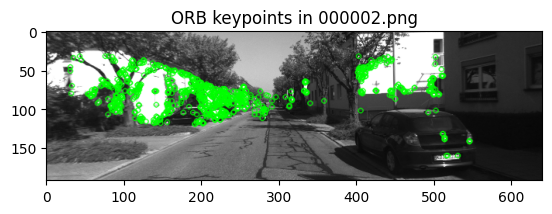

Extracting ORB features: 100%|██████████| 4541/4541 [00:47<00:00, 96.05it/s] 


Saved descriptors → orb_descriptors_seq00.npy


In [1]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# 1. Set paths
# -----------------------------
SEQ_PATH = "/Users/mayuri/Downloads/dataset/sequences/00/image_0"   
SAVE_DESCRIPTORS = True                                # store features for later matching

# -----------------------------
# 2. ORB feature extractor
# -----------------------------
orb = cv2.ORB_create(
    nfeatures=1000,     # number of keypoints per image
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=31,
    firstLevel=0,
    WTA_K=2,
    scoreType=cv2.ORB_HARRIS_SCORE,
    patchSize=31,
    fastThreshold=20
)

# -----------------------------
# 3. Read all image files
# -----------------------------
image_files = sorted([os.path.join(SEQ_PATH, f) for f in os.listdir(SEQ_PATH) if f.endswith('.png')])
print(f"Found {len(image_files)} images.")

# -----------------------------
# 4. Loop through images & extract features
# -----------------------------
features = []  # list of (keypoints, descriptors)

for img_path in tqdm(image_files, desc="Extracting ORB features"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Optional preprocessing
    img = cv2.resize(img, (640, 192))  # resize for consistency
    
    keypoints, descriptors = orb.detectAndCompute(img, None)
    features.append((keypoints, descriptors))
    
    # Visualization for first few images
    if len(features) <= 3:
        img_kp = cv2.drawKeypoints(img, keypoints, None, color=(0,255,0), flags=0)
        plt.imshow(img_kp, cmap='gray')
        plt.title(f"ORB keypoints in {os.path.basename(img_path)}")
        plt.show()

# -----------------------------
# 5. Save descriptors for later (optional)
# -----------------------------
if SAVE_DESCRIPTORS:
    descriptors_list = [f[1] for f in features]  # list of descriptor arrays
    np.save("orb_descriptors_seq00.npy", np.array(descriptors_list, dtype=object))
    print("Saved descriptors → orb_descriptors_seq00.npy")


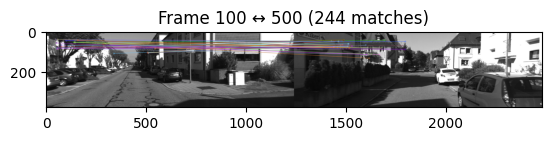

In [3]:
# -----------------------------
# 6. Descriptor Matching
# -----------------------------
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Example: match frame i with frame j (e.g., j = i + 50)
i, j = 100, 500
desc1 = features[i][1]
desc2 = features[j][1]

if desc1 is not None and desc2 is not None:
    matches = bf.match(desc1, desc2)
    matches = sorted(matches, key=lambda x: x.distance)

    img1 = cv2.imread(image_files[i], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image_files[j], cv2.IMREAD_GRAYSCALE)
    img_matches = cv2.drawMatches(img1, features[i][0], img2, features[j][0], matches[:50], None, flags=2)
    plt.imshow(img_matches)
    plt.title(f"Frame {i} ↔ {j} ({len(matches)} matches)")
    plt.show()


In [5]:
from collections import defaultdict

# -----------------------------
# 6. Place Recognition Logic — Top-10 Candidates
# -----------------------------
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
N = len(features)
revisit_candidates = defaultdict(list)  # i : list of (j, score)

for i in tqdm(range(100, N, 10), desc="Searching for revisit candidates"):
    desc_i = features[i][1]
    if desc_i is None:
        continue

    scores = []
    for j in range(0, i - 50, 10):  # avoid temporally close frames
        desc_j = features[j][1]
        if desc_j is None:
            continue
        matches = bf.match(desc_i, desc_j)
        if not matches:
            continue
        avg_dist = np.mean([m.distance for m in matches])
        score = 1 / avg_dist
        scores.append((j, score))

    # Take top-10 best matches as revisit candidates
    top_10 = sorted(scores, key=lambda x: -x[1])[:10]
    revisit_candidates[i] = top_10


Searching for revisit candidates: 100%|██████████| 445/445 [05:33<00:00,  1.34it/s]


In [7]:
# -----------------------------
# 7. Precision and Recall Evaluation
# -----------------------------

def is_true_revisit(i, j):
    # Assume that true revisits happen if frame distance is within 3 meters (~10 frames)
    # This is a simplification in absence of ground truth poses
    return abs(i - j) < 100  # Modify if you have access to GT poses

TP, FP, FN = 0, 0, 0
detected_revisits = set()

for i, candidates in revisit_candidates.items():
    found_true = False
    for j, score in candidates:
        if is_true_revisit(i, j):
            TP += 1
            found_true = True
            detected_revisits.add((i, j))
            break
    if not found_true:
        FP += 1

# For recall: how many actual revisits did we miss?
# Let’s define a revisit as occurring every 300 frames as a naive approximation
true_revisits = 0
for i in range(300, N, 300):
    j = i - 300
    if not any((i, j_) in detected_revisits for j_ in range(j - 50, j + 50)):
        FN += 1
    true_revisits += 1

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print(f"\n=== Evaluation Results ===")
print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


=== Evaluation Results ===
True Positives: 132
False Positives: 313
False Negatives: 15
Precision: 0.2966
Recall: 0.8980


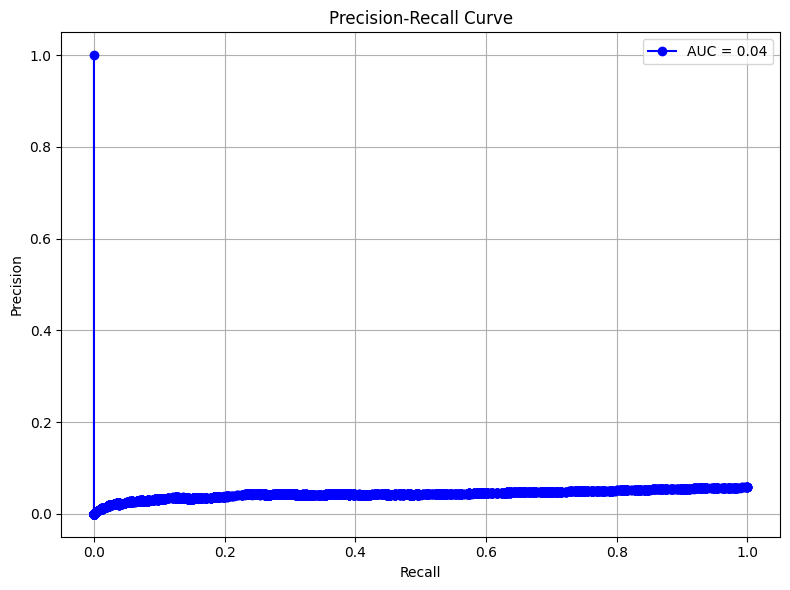


📈 AUC (Area Under Precision-Recall Curve): 0.0432


In [8]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# -----------------------------
# 8. PR Curve Data Preparation
# -----------------------------

# Flatten all scores and labels
all_scores = []
all_labels = []

for i, candidates in revisit_candidates.items():
    for j, score in candidates:
        all_scores.append(score)
        all_labels.append(1 if is_true_revisit(i, j) else 0)

# Compute precision-recall pairs and AUC
precision_vals, recall_vals, thresholds = precision_recall_curve(all_labels, all_scores)
pr_auc = auc(recall_vals, precision_vals)

# -----------------------------
# 9. Plot PR Curve
# -----------------------------
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, marker='o', color='blue', label=f'AUC = {pr_auc:.2f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve.png")
plt.show()

print(f"\n📈 AUC (Area Under Precision-Recall Curve): {pr_auc:.4f}")


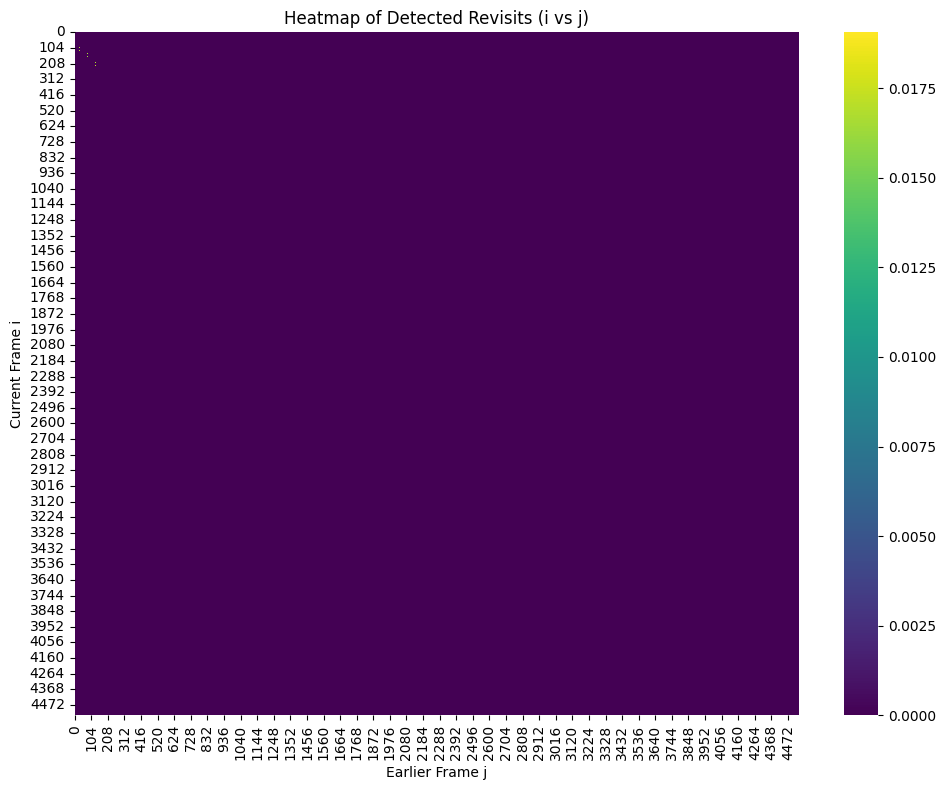

In [11]:
# heatmap of revisit detection
import seaborn as sns

match_matrix = np.zeros((N, N))
for i, candidates in revisit_candidates.items():
    for j, score in candidates:
        if is_true_revisit(i, j):
            match_matrix[i, j] = score

plt.figure(figsize=(10, 8))
sns.heatmap(match_matrix, cmap='viridis', cbar=True)
plt.title("Heatmap of Detected Revisits (i vs j)")
plt.xlabel("Earlier Frame j")
plt.ylabel("Current Frame i")
plt.tight_layout()
plt.savefig("revisit_heatmap.png")
plt.show()


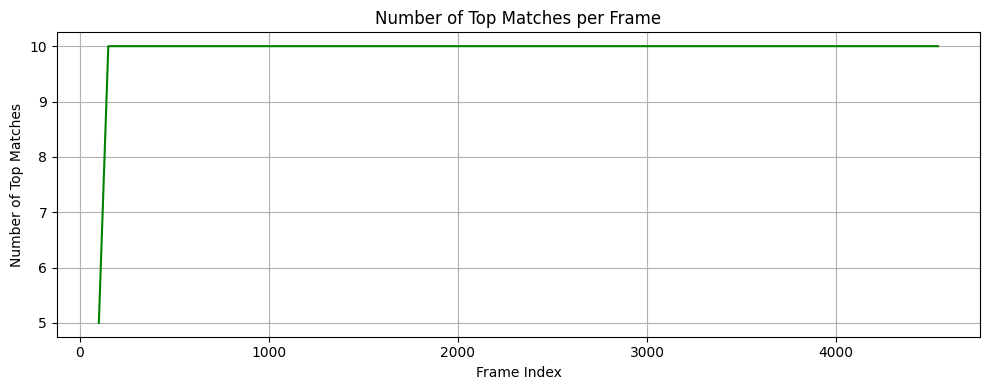

In [12]:
# matches per frame plot
matches_per_frame = [len(cands) for cands in revisit_candidates.values()]
frame_ids = list(revisit_candidates.keys())

plt.figure(figsize=(10, 4))
plt.plot(frame_ids, matches_per_frame, label='Top-10 Matches', color='green')
plt.xlabel("Frame Index")
plt.ylabel("Number of Top Matches")
plt.title("Number of Top Matches per Frame")
plt.grid(True)
plt.tight_layout()
plt.savefig("matches_per_frame.png")
plt.show()
